# BNPL Usage by Age Group Analysis

This notebook analyzes Buy Now Pay Later (BNPL) usage patterns across different age groups using the Federal Reserve's Survey of Household Economics and Decisionmaking (SHED) 2024 data. The analysis calculates the percentage of people in each age group who use BNPL services and creates a visualization suitable for Tableau.

## Section 1: Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

try:
    import seaborn as sns
    sns.set_style("whitegrid")
except ImportError:
    sns = None
    plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams['figure.figsize'] = (12, 6)

## Section 2: Load and Explore the Data

In [ ]:
# Load the data
df = pd.read_csv('public2024.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# Check for the relevant columns
print("\nColumn names (searching for BNPL, age, income, and education variables):")
bnpl_cols = [col for col in df.columns if 'bnpl' in col.lower()]
age_cols = [col for col in df.columns if 'ppage' in col.lower()]
income_cols = [col for col in df.columns if 'income' in col.lower() or 'inc' in col.lower()]
education_cols = [col for col in df.columns if 'educ' in col.lower() or 'school' in col.lower()]
print(f"BNPL columns: {bnpl_cols}")
print(f"Age columns: {age_cols}")
print(f"Income columns: {income_cols}")
print(f"Education columns: {education_cols}")

# Identify candidate late-payment question variables
late_cols = [col for col in df.columns if 'late' in col.lower() or 'delinq' in col.lower() or 'past' in col.lower() or 'due' in col.lower()]
print(f"Late-payment candidate columns: {late_cols}")

Dataset Shape: (12295, 751)

First few rows:
      shedid  duration  weight  weight_pop  panel_weight  panel_weight_pop  \
0  202203873      1333  0.6149  12971.9817        1.2153        78509.7641   
1  202204577       975  0.8301  17511.2242           NaN               NaN   
2  201800189      2146  0.4447   9381.0980        0.8061        52078.4957   
3  202406204      1214  0.8333  17580.0326           NaN               NaN   
4  202200780      1168  0.9064  19121.3763           NaN               NaN   

  xlaptop L0_a L0_b L0_c  ... E4_f_iflag CH2A_iflag race_5cat  \
0      No   No   No   No  ...          0          0     White   
1      No   No   No   No  ...          0          0     White   
2      No   No   No   No  ...          0          0     White   
3      No  Yes   No   No  ...          0          0     White   
4      No  Yes   No   No  ...          0          0     White   

       inc_4cat_50k                                    educ_4cat pay_casheqv  \
0   $25,000–$49

## Section 3: Filter and Prepare BNPL Data

In [ ]:
# Examine BNPL1 variable (Buy Now Pay Later usage)
print("BNPL1 Variable - Unique Values:")
print(df['BNPL1'].value_counts(dropna=False))
print(f"\nBNPL1 Data type: {df['BNPL1'].dtype}")
print(f"BNPL1 Missing values: {df['BNPL1'].isna().sum()}")

# Examine ppagecat variable (age category)
print("\n" + "="*60)
print("ppagecat Variable - Unique Values:")
print(df['ppagecat'].value_counts(dropna=False))
print(f"\nppagecat Data type: {df['ppagecat'].dtype}")
print(f"ppagecat Missing values: {df['ppagecat'].isna().sum()}")

# Examine income and education variables
print("\n" + "="*60)
print("inc_4cat_50k Variable - Unique Values:")
print(df['inc_4cat_50k'].value_counts(dropna=False))
print(f"\ninc_4cat_50k Data type: {df['inc_4cat_50k'].dtype}")
print(f"inc_4cat_50k Missing values: {df['inc_4cat_50k'].isna().sum()}")

print("\n" + "="*60)
print("educ_4cat Variable - Unique Values:")
print(df['educ_4cat'].value_counts(dropna=False))
print(f"\neduc_4cat Data type: {df['educ_4cat'].dtype}")
print(f"educ_4cat Missing values: {df['educ_4cat'].isna().sum()}")

# Create a working dataset with the selected variables
df_analysis = df[['shedid', 'BNPL1', 'ppagecat', 'inc_4cat_50k', 'educ_4cat', 'K8B']].copy()

# Show value counts
print("\n" + "="*60)
print("Data availability for analysis:")
print(f"Total rows: {len(df_analysis)}")
print(f"Rows with BNPL1 data: {df_analysis['BNPL1'].notna().sum()}")
print(f"Rows with ppagecat data: {df_analysis['ppagecat'].notna().sum()}")
print(f"Rows with inc_4cat_50k data: {df_analysis['inc_4cat_50k'].notna().sum()}")
print(f"Rows with educ_4cat data: {df_analysis['educ_4cat'].notna().sum()}")
print(f"Rows with BNPL1 and age data: {(df_analysis['BNPL1'].notna() & df_analysis['ppagecat'].notna()).sum()}")
print(f"Rows with BNPL1 and income data: {(df_analysis['BNPL1'].notna() & df_analysis['inc_4cat_50k'].notna()).sum()}")
print(f"Rows with BNPL1 and education data: {(df_analysis['BNPL1'].notna() & df_analysis['educ_4cat'].notna()).sum()}")

BNPL1 Variable - Unique Values:
BNPL1
No     10625
Yes     1670
Name: count, dtype: int64

BNPL1 Data type: str
BNPL1 Missing values: 0

ppagecat Variable - Unique Values:
ppagecat
55-64    2302
65-74    2219
35-44    2015
25-34    1799
45-54    1774
75+      1300
18-24     886
Name: count, dtype: int64

ppagecat Data type: str
ppagecat Missing values: 0

Data availability for analysis:
Total rows: 12295
Rows with BNPL1 data: 12295
Rows with ppagecat data: 12295
Rows with both BNPL1 and ppagecat data: 12295


In [ ]:
# Create a respondent-level master table with a primary key for relationships
# Use shedid as the unique respondent ID that can link age, income, and education.
df_master = df_analysis[['shedid', 'ppagecat', 'inc_4cat_50k', 'educ_4cat', 'BNPL1', 'K8B']].copy()
df_master = df_master.rename(columns={
    'shedid': 'RespondentID',
    'ppagecat': 'Age Group',
    'inc_4cat_50k': 'Income Group',
    'educ_4cat': 'Education Group',
    'BNPL1': 'BNPL User',
    'K8B': 'Late Payment Timing'
})
df_master['BNPL User'] = (df_master['BNPL User'] == 'Yes').astype(int)
df_master['Late Payment'] = df_master['Late Payment Timing'].notna().astype(int)

df_master.to_csv('master_bnpl_late_by_respondent.csv', index=False)
print("Master respondent-level file saved to 'master_bnpl_late_by_respondent.csv'")
print("Use RespondentID as the primary key to connect age, income, and education categories.")

## Section 4: Calculate BNPL Usage Percentage by Group

In [ ]:
# Helper function to compute BNPL summary for any category
def compute_bnpl_summary(df, group_col, group_label):
    df_group = df.dropna(subset=['BNPL1', group_col]).copy()
    df_group['uses_bnpl'] = (df_group['BNPL1'] == 'Yes').astype(int)

    summary = df_group.groupby(group_col).agg(
        total_respondents=('uses_bnpl', 'count'),
        bnpl_users=('uses_bnpl', 'sum'),
    ).reset_index()

    summary['bnpl_percentage'] = (summary['bnpl_users'] / summary['total_respondents'] * 100).round(2)
    summary = summary.rename(columns={group_col: group_label})
    return summary

# Compute BNPL summaries for age, income, and education
bnpl_by_age = compute_bnpl_summary(df_analysis, 'ppagecat', 'Age Group')
bnpl_by_income = compute_bnpl_summary(df_analysis, 'inc_4cat_50k', 'Income Group')
bnpl_by_education = compute_bnpl_summary(df_analysis, 'educ_4cat', 'Education Group')

print("BNPL Usage by Age Group:")
print(bnpl_by_age)
print("\nBNPL Usage by Income Group:")
print(bnpl_by_income)
print("\nBNPL Usage by Education Group:")
print(bnpl_by_education)

# Create formatted summaries for display
for df_name, summary in [
    ('Age Group', bnpl_by_age),
    ('Income Group', bnpl_by_income),
    ('Education Group', bnpl_by_education),
]:
    summary_display = summary.copy()
    summary_display['bnpl_percentage_str'] = summary_display['bnpl_percentage'].astype(str) + '%'
    print(f"\nFormatted Summary for {df_name}:")
    print(summary_display[[df_name, 'total_respondents', 'bnpl_users', 'bnpl_percentage_str']])

BNPL1 values in complete dataset:
BNPL1
No     10625
Yes     1670
Name: count, dtype: int64
BNPL Usage by Age Group:
  age_group  total_respondents  bnpl_users  bnpl_percentage
0     18-24                886         161            18.17
1     25-34               1799         350            19.46
2     35-44               2015         355            17.62
3     45-54               1774         280            15.78
4     55-64               2302         290            12.60
5     65-74               2219         180             8.11
6       75+               1300          54             4.15

Formatted Summary:
  age_group  total_respondents  bnpl_users bnpl_percentage_str
0     18-24                886         161              18.17%
1     25-34               1799         350              19.46%
2     35-44               2015         355              17.62%
3     45-54               1774         280              15.78%
4     55-64               2302         290               12.6%
5    

## Section 5: Create Visualization for Tableau Export

Chart saved as 'BNPL_by_age_group.png'


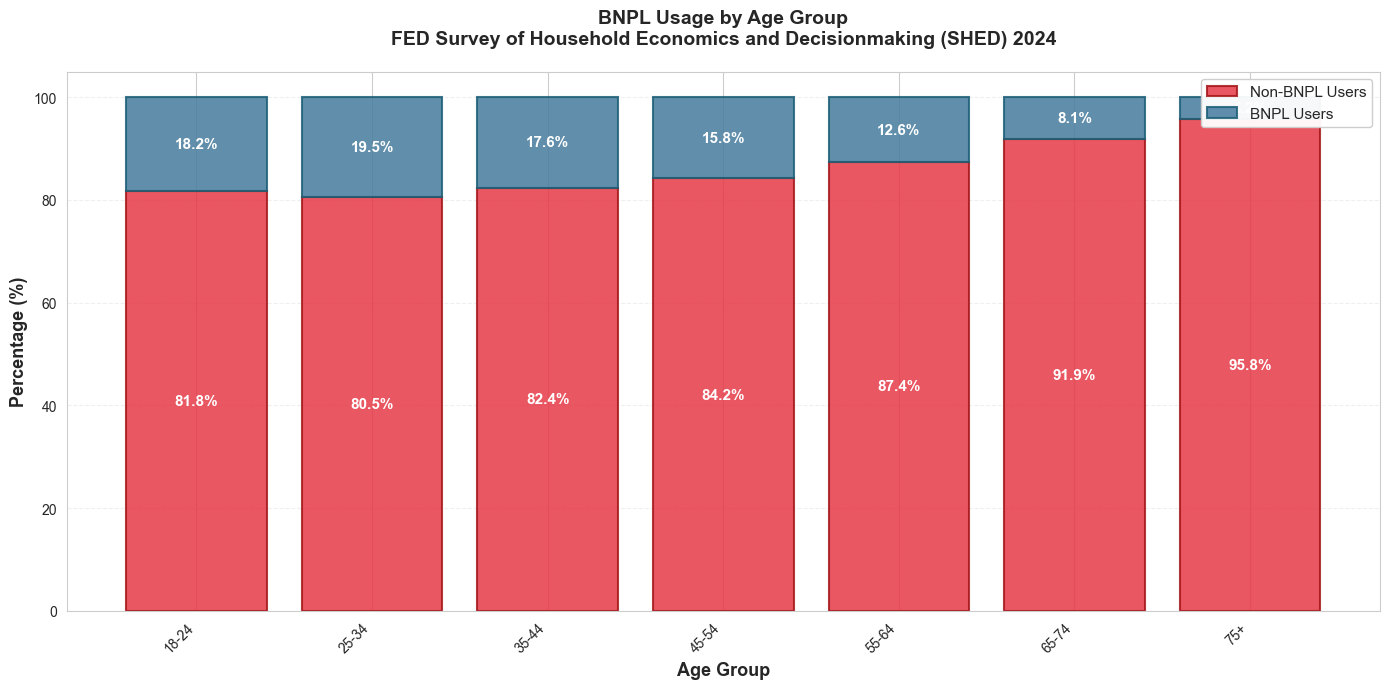

In [ ]:
# Create a reusable stacked bar chart function for Tableau export
def plot_bnpl_stacked_bar(summary_df, group_label, title, filename):
    summary = summary_df.copy()
    summary['non_bnpl_percentage'] = 100 - summary['bnpl_percentage']

    fig, ax = plt.subplots(figsize=(14, 7))
    x = range(len(summary))

    ax.bar(x, summary['non_bnpl_percentage'],
           label='Non-BNPL Users', color='#E63946', edgecolor='#A4161A', linewidth=1.5, alpha=0.85)
    ax.bar(x, summary['bnpl_percentage'],
           bottom=summary['non_bnpl_percentage'],
           label='BNPL Users', color='#457B9D', edgecolor='#1B5E75', linewidth=1.5, alpha=0.85)

    ax.set_xlabel(group_label, fontsize=13, fontweight='bold')
    ax.set_ylabel('Percentage (%)', fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)

    ax.set_xticks(x)
    ax.set_xticklabels(summary[group_label], rotation=45, ha='right')

    for i, (idx, row) in enumerate(summary.iterrows()):
        bnpl_pct = row['bnpl_percentage']
        non_bnpl_pct = row['non_bnpl_percentage']
        ax.text(i, non_bnpl_pct + bnpl_pct/2, f'{bnpl_pct:.1f}%',
                ha='center', va='center', fontsize=11, fontweight='bold', color='white')
        ax.text(i, non_bnpl_pct/2, f'{non_bnpl_pct:.1f}%',
                ha='center', va='center', fontsize=11, fontweight='bold', color='white')

    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.set_ylim(0, 105)
    ax.legend(loc='upper right', fontsize=11, framealpha=0.95)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Chart saved as '{filename}'")
    plt.show()

plot_bnpl_stacked_bar(
    bnpl_by_age,
    'Age Group',
    'BNPL Usage by Age Group\nFED Survey of Household Economics and Decisionmaking (SHED) 2024',
    'BNPL_by_age_group.png'
)
plot_bnpl_stacked_bar(
    bnpl_by_income,
    'Income Group',
    'BNPL Usage by Income Group\nFED Survey of Household Economics and Decisionmaking (SHED) 2024',
    'BNPL_by_income_group.png'
)
plot_bnpl_stacked_bar(
    bnpl_by_education,
    'Education Group',
    'BNPL Usage by Education Group\nFED Survey of Household Economics and Decisionmaking (SHED) 2024',
    'BNPL_by_education_group.png'
)

## Section 6: Export Data to CSV for Tableau Import

In [ ]:
# Export the analysis results to CSV for Tableau import
export_sets = [
    (bnpl_by_age, 'Age Group', 'bnpl_usage_by_age_group.csv'),
    (bnpl_by_income, 'Income Group', 'bnpl_usage_by_income_group.csv'),
    (bnpl_by_education, 'Education Group', 'bnpl_usage_by_education_group.csv'),
]

for summary_df, label, filename in export_sets:
    export_data = summary_df.copy()
    export_data.columns = [label, 'Total Respondents', 'BNPL Users', 'BNPL Usage Percentage']
    export_data.to_csv(filename, index=False)
    print(f"Data exported to '{filename}'")

# Display the final datasets and summary statistics
for label, summary_df in [
    ('Age Group', bnpl_by_age),
    ('Income Group', bnpl_by_income),
    ('Education Group', bnpl_by_education),
]:
    export_data = summary_df.copy()
    export_data.columns = [label, 'Total Respondents', 'BNPL Users', 'BNPL Usage Percentage']

    print("\n" + "="*80)
    print(f"FINAL DATA FOR TABLEAU IMPORT - {label}")
    print("="*80)
    print(export_data.to_string(index=False))

    print("\n" + "="*80)
    print(f"SUMMARY STATISTICS - {label}")
    print("="*80)
    print(f"Total respondents with complete data: {export_data['Total Respondents'].sum():,}")
    print(f"Total BNPL users: {export_data['BNPL Users'].sum():,}")
    print(f"Overall BNPL usage percentage: {(export_data['BNPL Users'].sum() / export_data['Total Respondents'].sum() * 100):.2f}%")
    print(f"{label} with highest BNPL usage: {export_data.loc[export_data['BNPL Usage Percentage'].idxmax(), label]} ({export_data['BNPL Usage Percentage'].max():.2f}%)")
    print(f"{label} with lowest BNPL usage: {export_data.loc[export_data['BNPL Usage Percentage'].idxmin(), label]} ({export_data['BNPL Usage Percentage'].min():.2f}%)")

Data exported to 'bnpl_usage_by_age_group.csv'

FINAL DATA FOR TABLEAU IMPORT
Age Group  Total Respondents  BNPL Users  BNPL Usage Percentage
    18-24                886         161                  18.17
    25-34               1799         350                  19.46
    35-44               2015         355                  17.62
    45-54               1774         280                  15.78
    55-64               2302         290                  12.60
    65-74               2219         180                   8.11
      75+               1300          54                   4.15

SUMMARY STATISTICS
Total respondents with complete data: 12,295
Total BNPL users: 1,670
Overall BNPL usage percentage: 13.58%

Age group with highest BNPL usage: 25-34 (19.46%)
Age group with lowest BNPL usage: 75+ (4.15%)


## Section 7: Late Payment Analysis by Age, Income, and Education
This section uses the late payment timing variable `K8B` to count how many respondents experienced a late payment and then summarizes that count by age, income, and education groups.

In [ ]:
# Ensure the working dataset is available before calculating late payments
if 'df_analysis' not in globals():
    if 'df' in globals():
        df_analysis = df[['BNPL1', 'ppagecat', 'inc_4cat_50k', 'educ_4cat', 'K8B']].copy()
    else:
        raise NameError("df_analysis is not defined. Run the data loading/preparation cells first.")

# Create BNPL and late payment indicators
bnpl_users = df_analysis['BNPL1'] == 'Yes'
df_analysis['bnpl_user'] = bnpl_users.astype(int)
df_analysis['late_payment'] = (df_analysis['K8B'].notna() & bnpl_users).astype(int)

# Summarize late payments among BNPL users by group
def compute_bnpl_late_summary(df, group_col, group_label):
    df_group = df.dropna(subset=[group_col]).copy()
    summary = df_group.groupby(group_col).agg(
        total_bnpl_users=('bnpl_user', 'sum'),
        late_payment_count=('late_payment', 'sum'),
    ).reset_index()
    summary['late_payment_pct'] = (summary['late_payment_count'] / summary['total_bnpl_users'] * 100).round(2)
    summary = summary.rename(columns={group_col: group_label})
    return summary

late_by_age = compute_bnpl_late_summary(df_analysis, 'ppagecat', 'Age Group')
late_by_income = compute_bnpl_late_summary(df_analysis, 'inc_4cat_50k', 'Income Group')
late_by_education = compute_bnpl_late_summary(df_analysis, 'educ_4cat', 'Education Group')

# Export late payment summaries to CSV
for summary_df, label, filename in [
    (late_by_age, 'Age Group', 'late_payments_by_age_group.csv'),
    (late_by_income, 'Income Group', 'late_payments_by_income_group.csv'),
    (late_by_education, 'Education Group', 'late_payments_by_education_group.csv'),
]:
    export_data = summary_df.copy()
    export_data.columns = [label, 'BNPL Users', 'Late Payment Count', 'Late Payment Percentage']
    export_data.to_csv(filename, index=False)
    print(f"Data exported to '{filename}'")

# Display the new late-payment summaries
for label, summary_df in [
    ('Age Group', late_by_age),
    ('Income Group', late_by_income),
    ('Education Group', late_by_education),
]:
    print("\n" + "="*80)
    print(f"LATE PAYMENT SUMMARY - {label}")
    print("="*80)
    display_df = summary_df.copy()
    display_df.columns = [label, 'BNPL Users', 'Late Payment Count', 'Late Payment Percentage']
    print(display_df.to_string(index=False))

NameError: name 'df_analysis' is not defined

In [ ]:
# Create an Excel workbook with all late-payment summary sheets
with pd.ExcelWriter('late_payments_by_group.xlsx', engine='openpyxl') as writer:
    late_by_age.to_excel(writer, sheet_name='Age Group', index=False)
    late_by_income.to_excel(writer, sheet_name='Income Group', index=False)
    late_by_education.to_excel(writer, sheet_name='Education Group', index=False)
print("All late payment summaries saved to 'late_payments_by_group.xlsx'")